In [57]:
import numpy as np
import matplotlib.pyplot as plt

# Note:
# There is only one metal being tested
# That metal is aluminium

# =========================================================
# TORSION TEST DATA
# =========================================================

# Specimen diameter
d_mm = 5.8
d = d_mm / 1000          # m
r = d / 2                # m

# Length of specimen
L_mm = 300
L = L_mm / 1000          # m

# =========================================================
# ELASTIC REGION
# =========================================================
# theta in degrees
# T in Nmm (assumed from table)


# Columns:
# [angle_deg, torsionmeter_reading_rad*1e-3, torque_Nmm]

elastic_data = np.array([
    [0.3,   3,    40],
    [0.6,   7,    60],
    [0.9,   11,  100],
    [1.2,   15,  140],
    [1.5,   19,  180],
    [1.8,   23,  200],
    [2.1,   27,  240],
    [2.4,   31,  260],
    [2.7,   35,  300],
    [3.0,   39,  340],
    [3.3,   42,  380],
    [3.6,   46,  420],
    [3.9,   50,  440],])

theta_elastic_deg = elastic_data[:, 0]
T_elastic_Nmm = elastic_data[:, 2]


theta_elastic_rad =  elastic_data[:, 1]*1e-3
T_elastic_Nm = T_elastic_Nmm / 1000


# =========================================================
# WHOLE EXPERIMENT
# =========================================================

whole_data = np.array([
    [0.3,   40],
    [0.6,   60],
    [0.9,  100],
    [1.2,  140],
    [1.5,  180],
    [1.8,  200],
    [2.1,  240],
    [2.4,  260],
    [2.7,  300],
    [3.0,  340],
    [3.3,  380],
    [3.6,  420],
    [3.9,  440],
    [4.2,  480],
    [4.5,  500],
    [4.8,  540],
    [5.1,  580],
    [5.4,  600],
    [5.7,  640],
    [6.0,  680],
    [6.3,  720],
    [6.6,  760],
    [7.2,  820],
    [7.8,  880],
    [8.4,  960],
    [9.0, 1020],
    [10.0, 1120],
    [11.0, 1220],
    [12.0, 1300],
    [13.0, 1400],
    [14.0, 1480],
    [15.0, 1540],
    [16.0, 1600],
    [17.0, 1660],
    [19.0, 1700],
    [20.0, 1800],
    [22.0, 1840],
    [24.0, 1880],
    [26.0, 1900],
    [28.0, 1920],
    [30.0, 1790],
])

theta_whole_deg = whole_data[:, 0]
T_whole_Nmm = whole_data[:, 1]

theta_whole_rad = np.deg2rad(theta_whole_deg)
T_whole_Nm = T_whole_Nmm / 1000

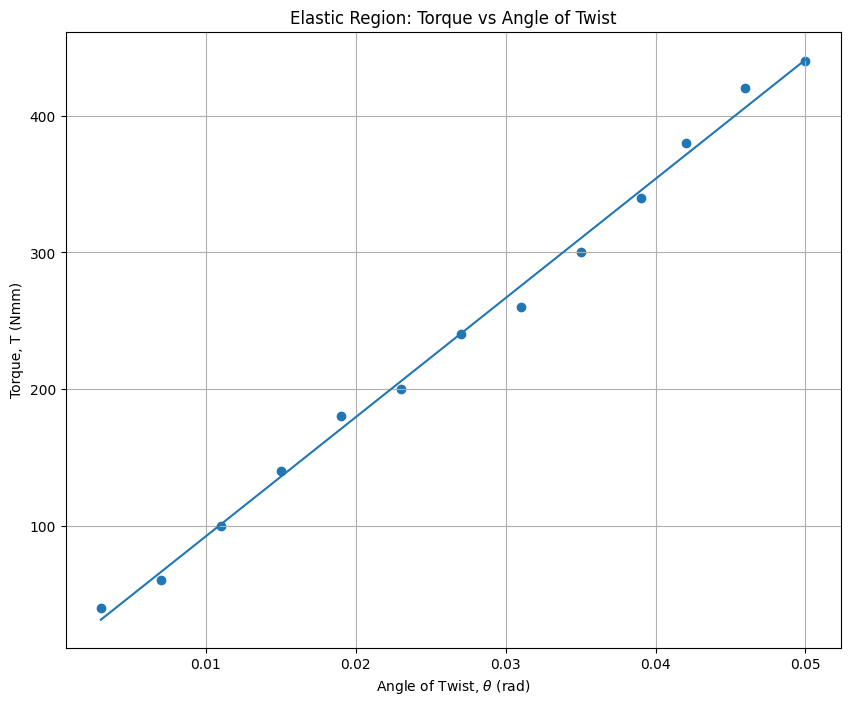

In [58]:
# =========================================================
# 1. GRAPH OF T AGAINST THETA (ELASTIC REGION)
# Torsiometer readings were used
# =========================================================

plt.figure(figsize=(10,8))
plt.scatter(theta_elastic_rad, T_elastic_Nmm, marker='o')

m, c = np.polyfit(theta_elastic_rad, T_elastic_Nmm, 1)

plt.plot(theta_elastic_rad, theta_elastic_rad*m+c)

plt.xlabel(r'Angle of Twist, $\theta$ (rad)')
plt.ylabel('Torque, T (Nmm)')
plt.title('Elastic Region: Torque vs Angle of Twist')

plt.grid(True)
plt.show()

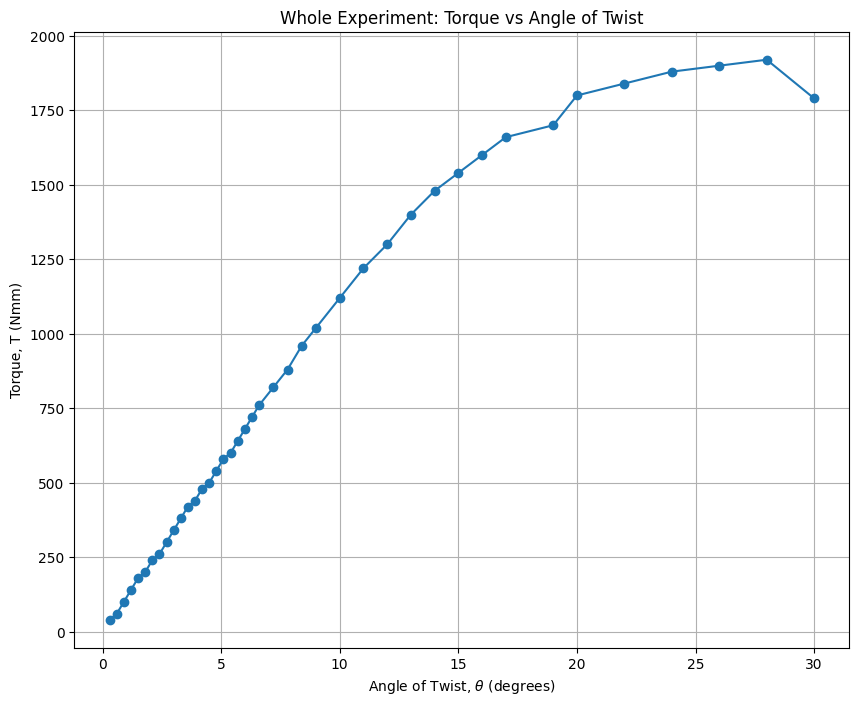

In [59]:
# =========================================================
# 2. GRAPH OF T AGAINST THETA (WHOLE EXPERIMENT)
# =========================================================

plt.figure(figsize=(10,8))
plt.plot(theta_whole_deg, T_whole_Nmm, marker='o')

plt.xlabel(r'Angle of Twist, $\theta$ (degrees)')
plt.ylabel('Torque, T (Nmm)')
plt.title('Whole Experiment: Torque vs Angle of Twist')

plt.grid(True)
plt.show()

In [60]:
# =========================================================
# 3. MODULUS OF RIGIDITY, G
# =========================================================

# Polar second moment of area for solid circular shaft:
# J = π d^4 / 32

J = (np.pi * d**4) / 32

# ---------------------------------------------------------
# Find slope of elastic region
# T = (GJ/L) * theta
#
# slope = T/theta = GJ/L
#
# Therefore:
# G = slope * L / J
# ---------------------------------------------------------

# Linear regression
slope, intercept = np.polyfit(theta_elastic_rad, T_elastic_Nm, 1)

G = (slope * L) / J

print("=================================================")
print("MODULUS OF RIGIDITY")
print("=================================================")
print(f"Slope dT/dθ = {slope:.4f} Nm/rad")
print(f"G = {G:.3e} Pa")
print(f"G = {G/1e9:.3f} GPa")


# =========================================================
# SHEAR STRESS AT YIELD
# =========================================================

# Approximate yield torque: based on graph observation

T_yield_Nmm = 1660
T_yield_Nm = T_yield_Nmm / 1000

# Maximum shear stress:
# τ = Tr/J

tau_yield = (T_yield_Nm * r) / J

print("\n=================================================")
print("SHEAR STRESS AT YIELD")
print("=================================================")
print(f"Yield Torque = {T_yield_Nmm} Nmm")
print(f"τ_y = {tau_yield:.3e} Pa")
print(f"τ_y = {tau_yield/1e6:.3f} MPa")

MODULUS OF RIGIDITY
Slope dT/dθ = 8.7161 Nm/rad
G = 2.354e+10 Pa
G = 23.536 GPa

SHEAR STRESS AT YIELD
Yield Torque = 1660 Nmm
τ_y = 4.333e+07 Pa
τ_y = 43.331 MPa
